## Neural Jump ODE on Toy Data
Generate train/test sets (n=5000 each), train a Neural Jump ODE sequence model, and evaluate with plots + metrics.

In [1]:
from pathlib import Path
import json

from toy_data.adapters import build_sequence_dataset

# Desired number of supervised next-step targets
n_examples = 5000
raw_train_n = n_examples + 1
raw_test_n = n_examples + 1

train_seed = 42
test_seed = 314

train_seq = build_sequence_dataset(n=raw_train_n, seed=train_seed)
test_seq = build_sequence_dataset(n=raw_test_n, seed=test_seed)

assert len(train_seq['x_seq']) == n_examples
assert len(test_seq['x_seq']) == n_examples

print('Train x_seq length:', len(train_seq['x_seq']))
print('Train y_flip_next length:', len(train_seq['y_flip_next']))
print('Test x_seq length:', len(test_seq['x_seq']))
print('Test y_flip_next length:', len(test_seq['y_flip_next']))

out_dir = Path('toy_data')
out_dir.mkdir(parents=True, exist_ok=True)
with (out_dir / 'neural_jump_ode_train_n5000.json').open('w', encoding='utf-8') as f:
    json.dump(train_seq, f)
with (out_dir / 'neural_jump_ode_test_n5000.json').open('w', encoding='utf-8') as f:
    json.dump(test_seq, f)

print('Saved: toy_data/neural_jump_ode_train_n5000.json')
print('Saved: toy_data/neural_jump_ode_test_n5000.json')

Train x_seq length: 5000
Train y_flip_next length: 5000
Test x_seq length: 5000
Test y_flip_next length: 5000
Saved: toy_data/neural_jump_ode_train_n5000.json
Saved: toy_data/neural_jump_ode_test_n5000.json


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader


class SequenceWindowDataset(Dataset):
    def __init__(self, seq_dict, seq_len=50):
        x_full = seq_dict['x_seq']
        y_full = seq_dict['y_flip_next']

        if len(x_full) != len(y_full):
            raise ValueError('x_seq and y_flip_next must have the same length')
        if len(x_full) < seq_len:
            raise ValueError('Sequence is too short for chosen seq_len')

        X = []
        Y = []
        for i in range(0, len(x_full) - seq_len + 1):
            X.append(x_full[i:i + seq_len])
            Y.append(y_full[i:i + seq_len])

        self.x = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        y_signed = torch.tensor(Y, dtype=torch.float32).unsqueeze(-1)
        self.y = (y_signed + 1.0) / 2.0

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


seq_len = 50
batch_size = 64

train_dataset = SequenceWindowDataset(train_seq, seq_len=seq_len)
test_dataset = SequenceWindowDataset(test_seq, seq_len=seq_len)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print('Train windows:', len(train_dataset))
print('Test windows:', len(test_dataset))
print('x shape:', tuple(xb.shape), '| y shape:', tuple(yb.shape))

Train windows: 4951
Test windows: 4951
x shape: (64, 50, 1) | y shape: (64, 50, 1)


In [3]:
import copy
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint


class ODEFunc(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
        )

    def forward(self, t, h):
        return self.net(h)


class ODEBlock(nn.Module):
    def __init__(self, odefunc):
        super().__init__()
        self.odefunc = odefunc
        self.integration_time = torch.tensor([0.0, 1.0], dtype=torch.float32)

    def forward(self, h):
        t = self.integration_time.to(h.device)
        h_path = odeint(self.odefunc, h, t, method='rk4')
        return h_path[-1]


class JumpUpdate(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size + input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
        )

    def forward(self, h, x_t):
        jump = self.net(torch.cat([h, x_t], dim=-1))
        return h + jump


class NeuralJumpODESequenceModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=96):
        super().__init__()
        self.hidden_size = hidden_size
        self.init_proj = nn.Linear(input_size, hidden_size)
        self.odeblock = ODEBlock(ODEFunc(hidden_size))
        self.jump = JumpUpdate(input_size, hidden_size)
        self.norm = nn.LayerNorm(hidden_size)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: [batch, seq_len, input_size]
        b, s, _ = x.shape
        h = torch.tanh(self.init_proj(x[:, 0, :]))
        outputs = []

        for t in range(s):
            if t > 0:
                h = self.odeblock(h)
                h = self.jump(h, x[:, t, :])
                h = self.norm(h)
            outputs.append(self.head(h))

        logits = torch.stack(outputs, dim=1)
        return logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NeuralJumpODESequenceModel(input_size=1, hidden_size=96).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)

epochs = 25
best_test_loss = float('inf')
best_epoch = 0
best_state = None

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)
            test_loss += loss.item() * xb.size(0)

            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.numel()

    test_loss /= len(test_loader.dataset)
    test_acc = correct / total

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    print(
        f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | '
        f'test_loss={test_loss:.4f} | test_acc={test_acc:.4f}'
    )

if best_state is not None:
    model.load_state_dict(best_state)
print(f'Loaded best checkpoint from epoch {best_epoch} with test_loss={best_test_loss:.4f}')

Epoch 01 | train_loss=0.6860 | test_loss=0.6737 | test_acc=0.5870
Epoch 02 | train_loss=0.6734 | test_loss=0.6665 | test_acc=0.6002
Epoch 03 | train_loss=0.6710 | test_loss=0.6641 | test_acc=0.6077
Epoch 04 | train_loss=0.6702 | test_loss=0.6633 | test_acc=0.6054
Epoch 05 | train_loss=0.6698 | test_loss=0.6634 | test_acc=0.6075
Epoch 06 | train_loss=0.6698 | test_loss=0.6640 | test_acc=0.6055
Epoch 07 | train_loss=0.6688 | test_loss=0.6636 | test_acc=0.6060
Epoch 08 | train_loss=0.6678 | test_loss=0.6619 | test_acc=0.6094
Epoch 09 | train_loss=0.6671 | test_loss=0.6627 | test_acc=0.6117
Epoch 10 | train_loss=0.6672 | test_loss=0.6623 | test_acc=0.6101
Epoch 11 | train_loss=0.6669 | test_loss=0.6614 | test_acc=0.6098
Epoch 12 | train_loss=0.6662 | test_loss=0.6618 | test_acc=0.6094
Epoch 13 | train_loss=0.6665 | test_loss=0.6617 | test_acc=0.6086
Epoch 14 | train_loss=0.6660 | test_loss=0.6627 | test_acc=0.6070
Epoch 15 | train_loss=0.6656 | test_loss=0.6628 | test_acc=0.6083
Epoch 16 |

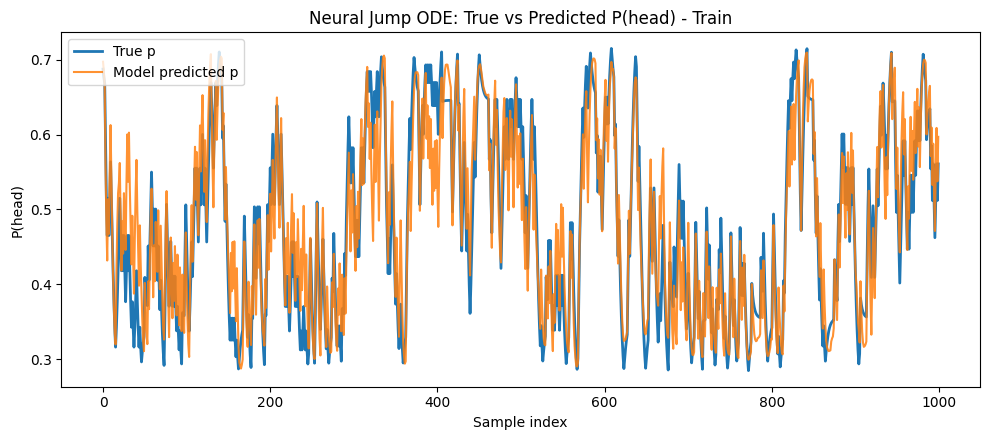

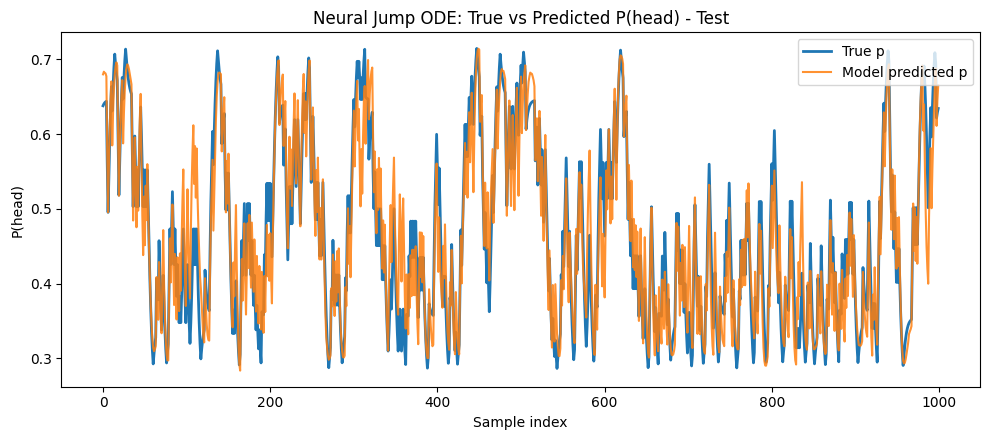

Saved: true_vs_pred_p_neural_jump_ode_train.png
Saved: true_vs_pred_p_neural_jump_ode_test.png
Saved: metrics_neural_jump_ode_comparison.png

           |   MAE   |  RMSE   |  Corr  
-----------|---------|---------|--------
Train      | 0.0336  | 0.0436  | 0.9357 
Test       | 0.0336  | 0.0435  | 0.9374 


In [4]:
import importlib
import toy_data
import toy_data.plotting as toy_plotting

importlib.reload(toy_plotting)
importlib.reload(toy_data)

from toy_data import (
    compute_true_vs_pred_metrics_torch_sequence,
    plot_true_vs_pred_p_over_samples_torch_sequence,
    save_metrics_comparison_table_png,
)

X_train_windows = train_dataset.x.cpu().tolist()
X_test_windows = test_dataset.x.cpu().tolist()
p_true_train_last = train_seq['y_p_next'][seq_len - 1:]
p_true_test_last = test_seq['y_p_next'][seq_len - 1:]

p_pred_train = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_neural_jump_ode_train.png',
    title='Neural Jump ODE: True vs Predicted P(head) - Train',
    show=True,
 )

p_pred_test = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_neural_jump_ode_test.png',
    title='Neural Jump ODE: True vs Predicted P(head) - Test',
    show=True,
 )

metrics_train = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
 )

metrics_test = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
 )

save_metrics_comparison_table_png(
    {'Train': metrics_train, 'Test': metrics_test},
    save_path='metrics_neural_jump_ode_comparison.png',
)

print('Saved: true_vs_pred_p_neural_jump_ode_train.png')
print('Saved: true_vs_pred_p_neural_jump_ode_test.png')
print('Saved: metrics_neural_jump_ode_comparison.png')
print()
print('           |   MAE   |  RMSE   |  Corr  ')
print('-----------|---------|---------|--------')
print('Train      | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_train['mae'], metrics_train['rmse'], metrics_train['corr']
))
print('Test       | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_test['mae'], metrics_test['rmse'], metrics_test['corr']
))

In [3]:
from pathlib import Path
import json

from toy_data.adapters import build_sequence_dataset

# Desired number of supervised next-step targets
n_examples = 5000
raw_train_n = n_examples + 1
raw_test_n = n_examples + 1

train_seed = 42
test_seed = 314

train_seq = build_sequence_dataset(n=raw_train_n, seed=train_seed, mode='probabilistic')
test_seq = build_sequence_dataset(n=raw_test_n, seed=test_seed, mode='probabilistic')

assert len(train_seq['x_seq']) == n_examples
assert len(test_seq['x_seq']) == n_examples

print('Train x_seq length:', len(train_seq['x_seq']))
print('Train y_flip_next length:', len(train_seq['y_flip_next']))
print('Test x_seq length:', len(test_seq['x_seq']))
print('Test y_flip_next length:', len(test_seq['y_flip_next']))

out_dir = Path('toy_data')
out_dir.mkdir(parents=True, exist_ok=True)
with (out_dir / 'neural_jump_ode_train_n5000_noisy.json').open('w', encoding='utf-8') as f:
    json.dump(train_seq, f)
with (out_dir / 'neural_jump_ode_test_n5000_noisy.json').open('w', encoding='utf-8') as f:
    json.dump(test_seq, f)

print('Saved: toy_data/neural_jump_ode_train_n5000_noisy.json')
print('Saved: toy_data/neural_jump_ode_test_n5000_noisy.json')

Train x_seq length: 5000
Train y_flip_next length: 5000
Test x_seq length: 5000
Test y_flip_next length: 5000
Saved: toy_data/neural_jump_ode_train_n5000_noisy.json
Saved: toy_data/neural_jump_ode_test_n5000_noisy.json


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader


class SequenceWindowDataset(Dataset):
    def __init__(self, seq_dict, seq_len=50):
        x_full = seq_dict['x_seq']
        y_full = seq_dict['y_flip_next']

        if len(x_full) != len(y_full):
            raise ValueError('x_seq and y_flip_next must have the same length')
        if len(x_full) < seq_len:
            raise ValueError('Sequence is too short for chosen seq_len')

        X = []
        Y = []
        for i in range(0, len(x_full) - seq_len + 1):
            X.append(x_full[i:i + seq_len])
            Y.append(y_full[i:i + seq_len])

        self.x = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        y_signed = torch.tensor(Y, dtype=torch.float32).unsqueeze(-1)
        self.y = (y_signed + 1.0) / 2.0

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


seq_len = 50
batch_size = 64

train_dataset = SequenceWindowDataset(train_seq, seq_len=seq_len)
test_dataset = SequenceWindowDataset(test_seq, seq_len=seq_len)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print('Train windows:', len(train_dataset))
print('Test windows:', len(test_dataset))
print('x shape:', tuple(xb.shape), '| y shape:', tuple(yb.shape))

Train windows: 4951
Test windows: 4951
x shape: (64, 50, 1) | y shape: (64, 50, 1)


In [5]:
import copy
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint


class ODEFunc(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
        )

    def forward(self, t, h):
        return self.net(h)


class ODEBlock(nn.Module):
    def __init__(self, odefunc):
        super().__init__()
        self.odefunc = odefunc
        self.integration_time = torch.tensor([0.0, 1.0], dtype=torch.float32)

    def forward(self, h):
        t = self.integration_time.to(h.device)
        h_path = odeint(self.odefunc, h, t, method='rk4')
        return h_path[-1]


class JumpUpdate(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size + input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
        )

    def forward(self, h, x_t):
        jump = self.net(torch.cat([h, x_t], dim=-1))
        return h + jump


class NeuralJumpODESequenceModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=96):
        super().__init__()
        self.hidden_size = hidden_size
        self.init_proj = nn.Linear(input_size, hidden_size)
        self.odeblock = ODEBlock(ODEFunc(hidden_size))
        self.jump = JumpUpdate(input_size, hidden_size)
        self.norm = nn.LayerNorm(hidden_size)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: [batch, seq_len, input_size]
        b, s, _ = x.shape
        h = torch.tanh(self.init_proj(x[:, 0, :]))
        outputs = []

        for t in range(s):
            if t > 0:
                h = self.odeblock(h)
                h = self.jump(h, x[:, t, :])
                h = self.norm(h)
            outputs.append(self.head(h))

        logits = torch.stack(outputs, dim=1)
        return logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NeuralJumpODESequenceModel(input_size=1, hidden_size=96).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)

epochs = 25
best_test_loss = float('inf')
best_epoch = 0
best_state = None

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)
            test_loss += loss.item() * xb.size(0)

            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.numel()

    test_loss /= len(test_loader.dataset)
    test_acc = correct / total

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    print(
        f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | '
        f'test_loss={test_loss:.4f} | test_acc={test_acc:.4f}'
    )

if best_state is not None:
    model.load_state_dict(best_state)
print(f'Loaded best checkpoint from epoch {best_epoch} with test_loss={best_test_loss:.4f}')

Epoch 01 | train_loss=0.6841 | test_loss=0.6835 | test_acc=0.5599
Epoch 02 | train_loss=0.6732 | test_loss=0.6827 | test_acc=0.5659
Epoch 03 | train_loss=0.6737 | test_loss=0.6835 | test_acc=0.5637
Epoch 04 | train_loss=0.6739 | test_loss=0.6826 | test_acc=0.5686
Epoch 05 | train_loss=0.6724 | test_loss=0.6826 | test_acc=0.5686
Epoch 06 | train_loss=0.6723 | test_loss=0.6832 | test_acc=0.5656
Epoch 07 | train_loss=0.6718 | test_loss=0.6826 | test_acc=0.5665
Epoch 08 | train_loss=0.6716 | test_loss=0.6831 | test_acc=0.5678
Epoch 09 | train_loss=0.6719 | test_loss=0.6815 | test_acc=0.5704
Epoch 10 | train_loss=0.6714 | test_loss=0.6830 | test_acc=0.5675
Epoch 11 | train_loss=0.6716 | test_loss=0.6843 | test_acc=0.5657
Epoch 12 | train_loss=0.6717 | test_loss=0.6836 | test_acc=0.5681
Epoch 13 | train_loss=0.6712 | test_loss=0.6828 | test_acc=0.5665
Epoch 14 | train_loss=0.6705 | test_loss=0.6826 | test_acc=0.5682
Epoch 15 | train_loss=0.6702 | test_loss=0.6831 | test_acc=0.5680
Epoch 16 |

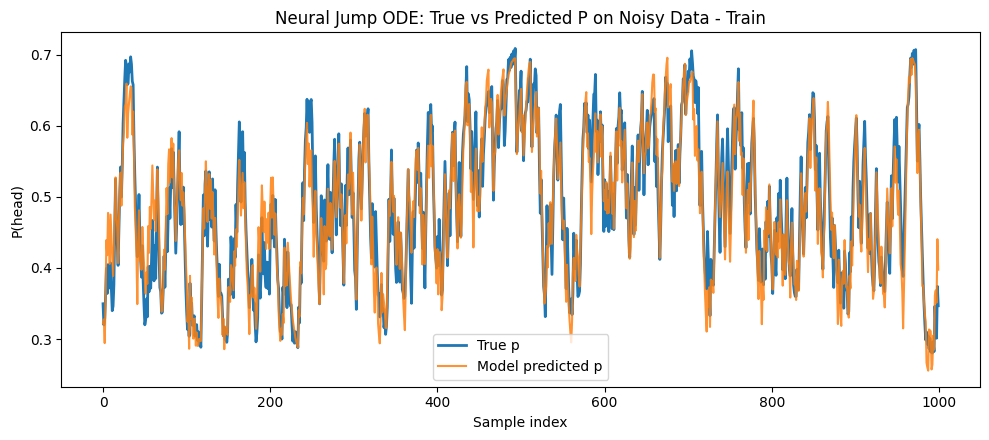

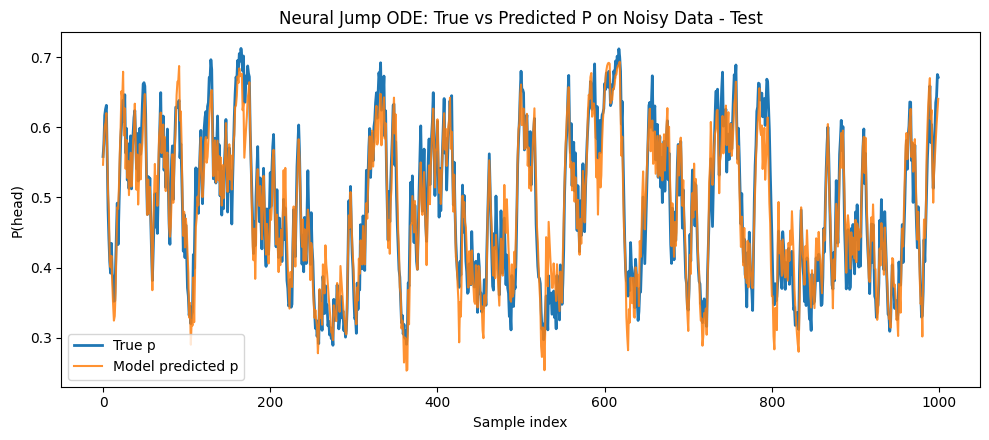

Saved: true_vs_pred_p_neural_jump_ode_train_noisy.png
Saved: true_vs_pred_p_neural_jump_ode_test_noisy.png
Saved: metrics_neural_jump_ode_comparison_noisy.png

           |   MAE   |  RMSE   |  Corr  
-----------|---------|---------|--------
Train      | 0.0262  | 0.0329  | 0.9525 
Test       | 0.0256  | 0.0324  | 0.9521 


In [6]:
import importlib
import toy_data
import toy_data.plotting as toy_plotting

importlib.reload(toy_plotting)
importlib.reload(toy_data)

from toy_data import (
    compute_true_vs_pred_metrics_torch_sequence,
    plot_true_vs_pred_p_over_samples_torch_sequence,
    save_metrics_comparison_table_png,
)

X_train_windows = train_dataset.x.cpu().tolist()
X_test_windows = test_dataset.x.cpu().tolist()
p_true_train_last = train_seq['y_p_next'][seq_len - 1:]
p_true_test_last = test_seq['y_p_next'][seq_len - 1:]

p_pred_train = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_neural_jump_ode_train_noisy.png',
    title='Neural Jump ODE: True vs Predicted P on Noisy Data - Train',
    show=True,
 )

p_pred_test = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_neural_jump_ode_test_noisy.png',
    title='Neural Jump ODE: True vs Predicted P on Noisy Data - Test',
    show=True,
 )

metrics_train = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
 )

metrics_test = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
 )

save_metrics_comparison_table_png(
    {'Train': metrics_train, 'Test': metrics_test},
    save_path='metrics_neural_jump_ode_comparison_noisy.png',
)

print('Saved: true_vs_pred_p_neural_jump_ode_train_noisy.png')
print('Saved: true_vs_pred_p_neural_jump_ode_test_noisy.png')
print('Saved: metrics_neural_jump_ode_comparison_noisy.png')
print()
print('           |   MAE   |  RMSE   |  Corr  ')
print('-----------|---------|---------|--------')
print('Train      | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_train['mae'], metrics_train['rmse'], metrics_train['corr']
))
print('Test       | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_test['mae'], metrics_test['rmse'], metrics_test['corr']
))